# Marching Qubes Classical Vertex Classification V1 (3D)
## Brandon Watanabe

3D volumes are rendered with **VTK** (`import vtk`). Each sample is a sphere at a marching-cubes vertex; 1D/2D views still use matplotlib.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import vtk
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy

# VTK rendering factories (required in some Jupyter kernels)
import vtkmodules.vtkRenderingOpenGL2  # noqa: F401
import vtkmodules.vtkInteractionStyle  # noqa: F401
import vtkmodules.vtkRenderingFreeType  # noqa: F401

In [40]:
"""
 Summary:
    Perform Marching Cubes vertex classification on a scalar field.
    Each vertex is classified according to a threshold isolevel:
        return 1    if input_val > isolevel
        return 0    otherwise

Parameters:
    input_val : int
        Intensity values in range [0, 255].

    isolevel : int
        Threshold value for classification.

Returns:
    int values in range [0, 1].
"""
def classify_vertex_classical(input_val, isolevel):
    return int(input_val > isolevel)

In [41]:
"""
Summary:
    Create a dataset of 4 different 1D arrays.
    Arrays will be 16 values in length in varying patterns:
        - 8x 00s / 8x FFs
        - 4x 00s / 4x FFs / 4x 00s / 4x FFs
        - 2x... 2x...
        - Alternating 00 FF 00 FF...

Parameters:
    None

Returns:
    Dictionary of 1D numpy arrays containing 16 8-bit values
"""
def construct_1D_datasets():
    datasets = {}

    # 8x 00 / 8x FFs
    datasets["8-block"] = np.array([0]*8 + [255]*8)

    # 4x 00s / 4x FFs / 4x 00s / 4x FFs
    datasets["4-block"] = np.array([0]*4 + [255]*4 + [0]*4 + [255]*4)

    # 2x... 2x...
    datasets["2-block"] = np.tile([0,0,255,255], 4)

    # Alternating 00 FF 00 FF...
    datasets["1-block"] = np.tile([0,255], 8)

    return datasets

In [42]:
"""
Summary:
    Create a dataset of 4 different 2D arrays.
    Arrays will be 16x16 values in length in varying patterns:
        - half/half vertically
        - half/half horizontally
        - quarter/quarter 
        - checkerboard

Parameters:
    None

Returns:
    Dictionary of 2D numpy arrays containing 16x16 8-bit values
"""
def construct_2D_datasets(size=16):
    half = size // 2
    
    datasets = {}

    # Vertical half/half
    vertical = np.zeros((size, size), dtype=np.uint8)
    vertical[:, half:] = 255
    datasets["vertical_h/h"] = vertical

    # Horizontal half/half
    horizontal = np.zeros((size, size), dtype=np.uint8)
    horizontal[half:, :] = 255
    datasets["horizontal_h/h"] = horizontal

    # Quarter / Quarter 
    quadrant = np.zeros((size, size), dtype=np.uint8)
    quadrant[:half, half:] = 255
    quadrant[half:, :half] = 255
    datasets["quadrant_split"] = quadrant

    # Checkerboard 
    checkerboard = (np.indices((size, size)).sum(axis=0) % 2) * 255
    datasets["checkerboard"] = checkerboard.astype(np.uint8)

    return datasets

In [43]:
"""
Summary:
    Create a dataset of 3D volumes.
    Arrays will be 16x16x16 values in varying patterns:
        - half/half along x, y, and z
        - octant split (3D analog of the 2D quadrant split)
        - 3D checkerboard

Parameters:
    size : int
        Edge length of the cubic volume.

Returns:
    Dictionary of 3D numpy arrays containing size x size x size 8-bit values
"""
def construct_3D_datasets(size=16):
    half = size // 2
    datasets = {}

    # Half/half along x
    x_split = np.zeros((size, size, size), dtype=np.uint8)
    x_split[half:, :, :] = 255
    datasets["x_h/h"] = x_split

    # Half/half along y
    y_split = np.zeros((size, size, size), dtype=np.uint8)
    y_split[:, half:, :] = 255
    datasets["y_h/h"] = y_split

    # Half/half along z
    z_split = np.zeros((size, size, size), dtype=np.uint8)
    z_split[:, :, half:] = 255
    datasets["z_h/h"] = z_split

    # Octant split: 3D analog of quadrant XOR
    xi, yi, zi = np.indices((size, size, size))
    octant = np.zeros((size, size, size), dtype=np.uint8)
    octant[(xi >= half) ^ (yi >= half) ^ (zi >= half)] = 255
    datasets["octant_split"] = octant

    # 3D checkerboard
    checkerboard = (np.indices((size, size, size)).sum(axis=0) % 2) * 255
    datasets["checkerboard"] = checkerboard.astype(np.uint8)

    return datasets


In [44]:
def visualize_classification_1D(inputs, outputs):
    for name in inputs.keys():

        fig, ax = plt.subplots(1, 2, figsize=(8, 1))

        ax[0].imshow(inputs[name].reshape(1, -1), cmap='gray', aspect='auto')
        ax[0].set_title(f"{name} - Input")

        ax[1].imshow(outputs[name].reshape(1, -1), cmap='hot', aspect='auto')
        ax[1].set_title("Classified")
        
        fig.colorbar(ax[1].images[0], ax=ax[1])

        plt.show()

def visualize_classification_2D(inputs, outputs):
    for name in inputs.keys():
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))

        ax[0].imshow(inputs[name], cmap='gray')
        ax[0].set_title(f"{name} - Input")

        ax[1].imshow(outputs[name], cmap='hot')
        ax[1].set_title("Classified")
        
        fig.colorbar(ax[1].images[0], ax=ax[1])

        plt.show()


def _mpl_cmap_to_vtk_lut(cmap_name, vmin, vmax, n=256):
    """Copy a matplotlib colormap into a VTK lookup table."""
    cmap = plt.get_cmap(cmap_name)
    lut = vtk.vtkLookupTable()
    lut.SetNumberOfTableValues(n)
    lut.SetRange(float(vmin), float(vmax))
    for i in range(n):
        r, g, b, a = cmap(i / max(n - 1, 1))
        lut.SetTableValue(i, float(r), float(g), float(b), float(a))
    lut.Build()
    return lut


def _classified_hot_lut():
    """Hot colormap compressed so class 1 is orange-red, not yellow-white."""
    cmap = plt.get_cmap("hot")
    lut = vtk.vtkLookupTable()
    lut.SetNumberOfTableValues(256)
    lut.SetRange(0.0, 1.0)
    for i in range(256):
        r, g, b, a = cmap(0.62 * (i / 255.0))
        lut.SetTableValue(i, float(r), float(g), float(b), float(a))
    lut.Build()
    return lut


def _volume_to_vertex_actor(volume, lut, vmin, vmax, radius=0.3):
    """
    Build a VTK actor of spheres at vertices with value > 0.
    Sphere centers sit on integer coordinates so each glyph is a
    marching-cubes vertex, not a filled cell.
    """
    volume = np.asarray(volume)
    coords = np.argwhere(volume > 0)

    poly = vtk.vtkPolyData()
    if coords.size:
        centers = np.ascontiguousarray(coords.astype(np.float64))
        values = np.ascontiguousarray(volume[tuple(coords.T)].astype(np.float64))
        points = vtk.vtkPoints()
        points.SetData(numpy_to_vtk(centers, deep=True))
        scalars = numpy_to_vtk(values, deep=True)
        scalars.SetName("intensity")
        poly.SetPoints(points)
        poly.GetPointData().SetScalars(scalars)

    sphere = vtk.vtkSphereSource()
    sphere.SetRadius(radius)
    sphere.SetPhiResolution(16)
    sphere.SetThetaResolution(16)

    glyph = vtk.vtkGlyph3D()
    glyph.SetSourceConnection(sphere.GetOutputPort())
    glyph.SetInputData(poly)
    glyph.SetColorModeToColorByScalar()
    glyph.SetScaleModeToDataScalingOff()
    glyph.Update()

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(glyph.GetOutputPort())
    mapper.SetLookupTable(lut)
    mapper.SetScalarRange(float(vmin), float(vmax))
    mapper.SetColorModeToMapScalars()
    mapper.ScalarVisibilityOn()

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetAmbient(0.4)
    actor.GetProperty().SetDiffuse(0.6)
    actor.GetProperty().SetSpecular(0.35)
    actor.GetProperty().SetSpecularPower(20)
    return actor


def _outline_actor(nx, ny, nz):
    source = vtk.vtkCubeSource()
    source.SetBounds(0, nx - 1, 0, ny - 1, 0, nz - 1)
    outline = vtk.vtkOutlineFilter()
    outline.SetInputConnection(source.GetOutputPort())
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(outline.GetOutputPort())
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(0.85, 0.85, 0.85)
    actor.GetProperty().SetLineWidth(1.5)
    return actor


def _text_actor(text, x, y):
    actor = vtk.vtkTextActor()
    actor.SetInput(text)
    prop = actor.GetTextProperty()
    prop.SetFontSize(16)
    prop.SetBold(1)
    prop.SetColor(1.0, 1.0, 1.0)
    actor.GetPositionCoordinate().SetCoordinateSystemToNormalizedViewport()
    actor.SetPosition(x, y)
    return actor


def _vtk_rgb_screenshot(render_window):
    render_window.Render()
    w2if = vtk.vtkWindowToImageFilter()
    w2if.SetInput(render_window)
    w2if.SetInputBufferTypeToRGB()
    w2if.ReadFrontBufferOff()
    w2if.Update()
    vtk_img = w2if.GetOutput()
    width, height, _ = vtk_img.GetDimensions()
    rgb = vtk_to_numpy(vtk_img.GetPointData().GetScalars()).reshape(height, width, 3)
    return np.ascontiguousarray(np.flipud(rgb))


def visualize_classification_3D(inputs, outputs, interactive=False):
    """
    Side-by-side VTK vertex views of each 3D input volume and its classified result.
    Only vertices with value > 0 are drawn so the 0-region stays hollow.
    Set interactive=True to rotate in a VTK window (blocks until the window closes).
    """
    for name in inputs.keys():
        volume_in = np.asarray(inputs[name])
        volume_out = np.asarray(outputs[name])
        nx, ny, nz = volume_in.shape

        lut_in = _mpl_cmap_to_vtk_lut("gray", 0, 255)
        lut_out = _classified_hot_lut()

        actor_in = _volume_to_vertex_actor(volume_in, lut_in, 0, 255)
        actor_out = _volume_to_vertex_actor(volume_out, lut_out, 0, 1)

        camera = vtk.vtkCamera()
        camera.SetViewUp(0, 0, 1)
        camera.SetPosition(nx * 2.4, ny * -2.1, nz * 1.8)
        camera.SetFocalPoint((nx - 1) / 2.0, (ny - 1) / 2.0, (nz - 1) / 2.0)

        ren_in = vtk.vtkRenderer()
        ren_in.SetViewport(0.0, 0.0, 0.5, 1.0)
        ren_in.SetBackground(0.12, 0.12, 0.14)
        ren_in.SetActiveCamera(camera)
        ren_in.AddActor(actor_in)
        ren_in.AddActor(_outline_actor(nx, ny, nz))
        ren_in.AddActor(_text_actor(f"{name} - Input", 0.04, 0.93))

        ren_out = vtk.vtkRenderer()
        ren_out.SetViewport(0.5, 0.0, 1.0, 1.0)
        ren_out.SetBackground(0.12, 0.12, 0.14)
        ren_out.SetActiveCamera(camera)
        ren_out.AddActor(actor_out)
        ren_out.AddActor(_outline_actor(nx, ny, nz))
        ren_out.AddActor(_text_actor("Classified", 0.04, 0.93))

        scalar_bar = vtk.vtkScalarBarActor()
        scalar_bar.SetLookupTable(lut_out)
        scalar_bar.SetTitle("class")
        scalar_bar.SetNumberOfLabels(2)
        scalar_bar.SetWidth(0.12)
        scalar_bar.SetHeight(0.4)
        scalar_bar.SetPosition(0.84, 0.08)
        scalar_bar.GetTitleTextProperty().SetFontSize(12)
        scalar_bar.GetLabelTextProperty().SetFontSize(10)
        ren_out.AddActor(scalar_bar)

        render_window = vtk.vtkRenderWindow()
        render_window.AddRenderer(ren_in)
        render_window.AddRenderer(ren_out)
        render_window.SetSize(1100, 520)
        render_window.SetWindowName(f"{name} vertex classification")
        camera.OrthogonalizeViewUp()
        ren_in.ResetCameraClippingRange()
        ren_out.ResetCameraClippingRange()

        if interactive:
            render_window.SetOffScreenRendering(0)
            interactor = vtk.vtkRenderWindowInteractor()
            interactor.SetRenderWindow(render_window)
            style = vtk.vtkInteractorStyleTrackballCamera()
            interactor.SetInteractorStyle(style)
            render_window.Render()
            interactor.Start()
        else:
            render_window.SetOffScreenRendering(1)
            rgb = _vtk_rgb_screenshot(render_window)
            fig, ax = plt.subplots(figsize=(11, 5.2))
            ax.imshow(rgb)
            ax.set_axis_off()
            ax.set_title(f"{name} (VTK vertices; value > 0 shown)")
            plt.show()


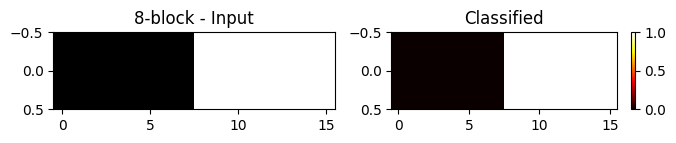

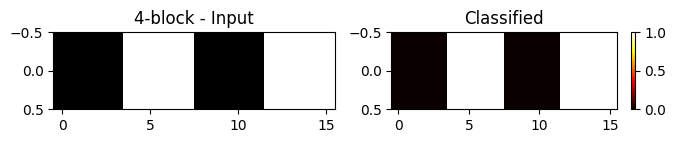

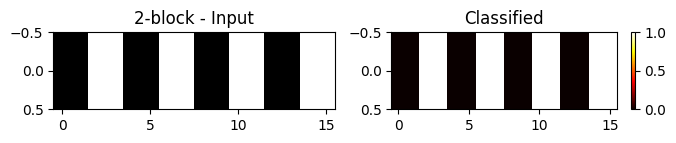

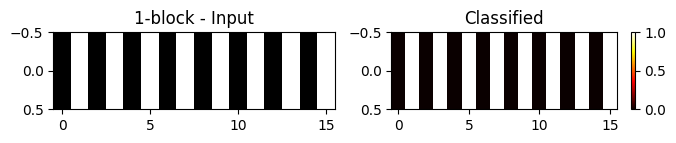

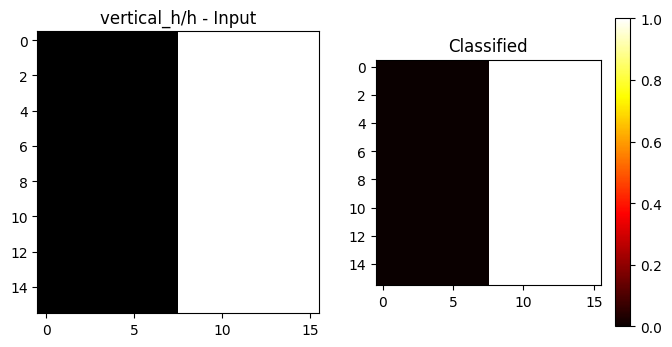

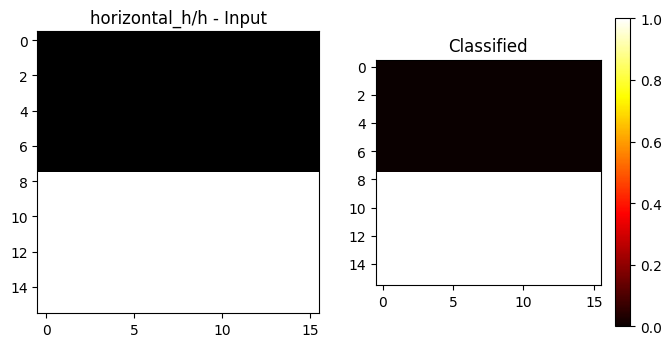

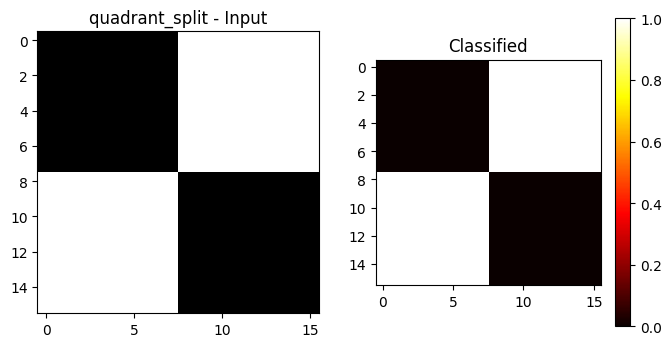

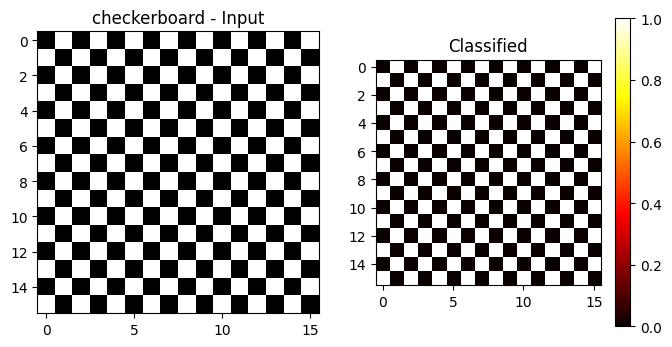

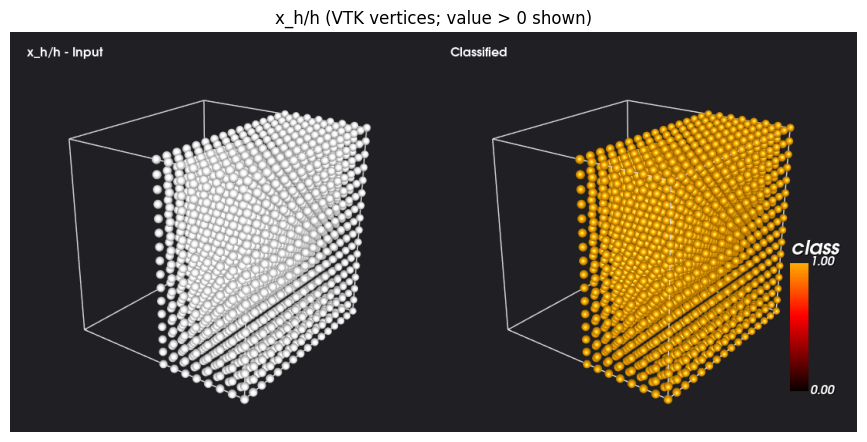

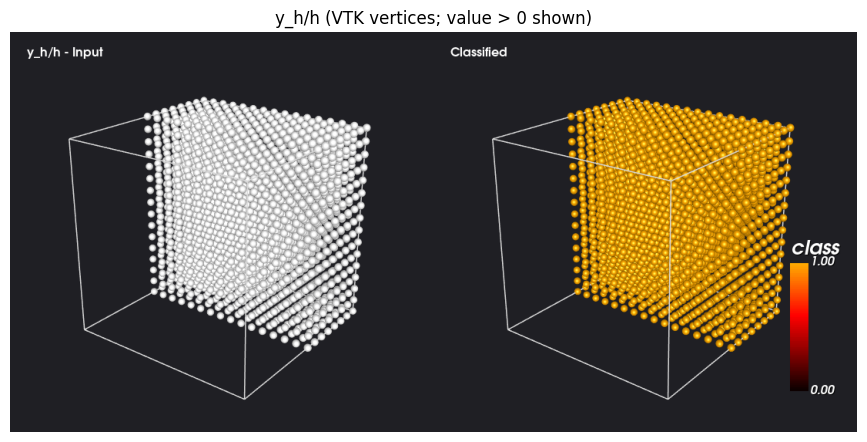

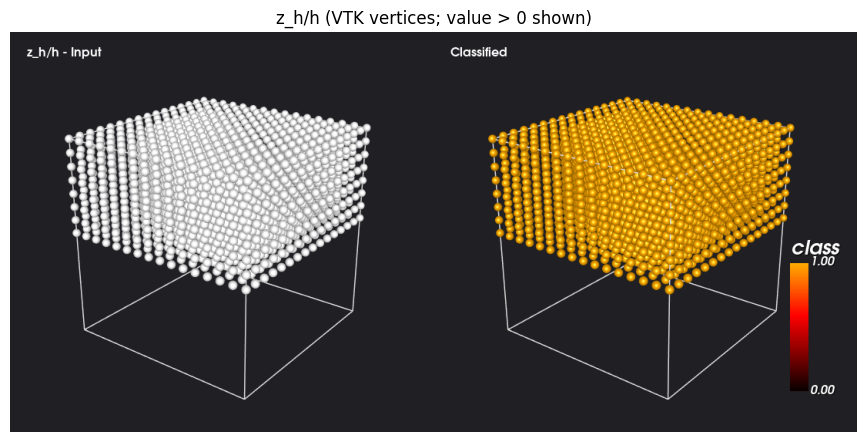

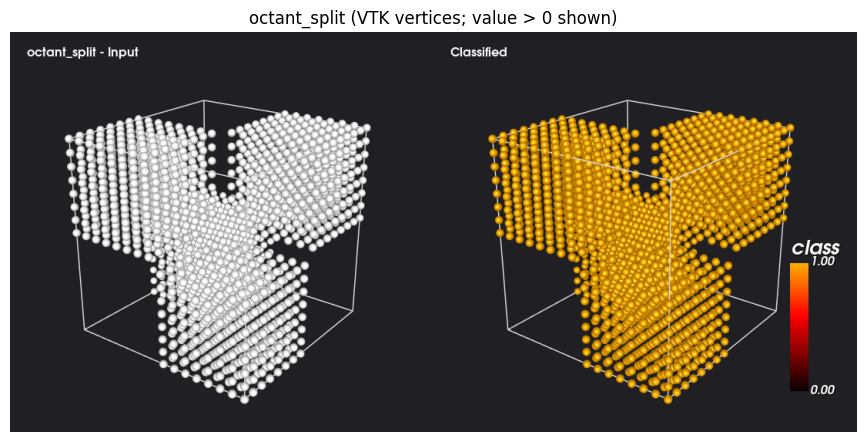

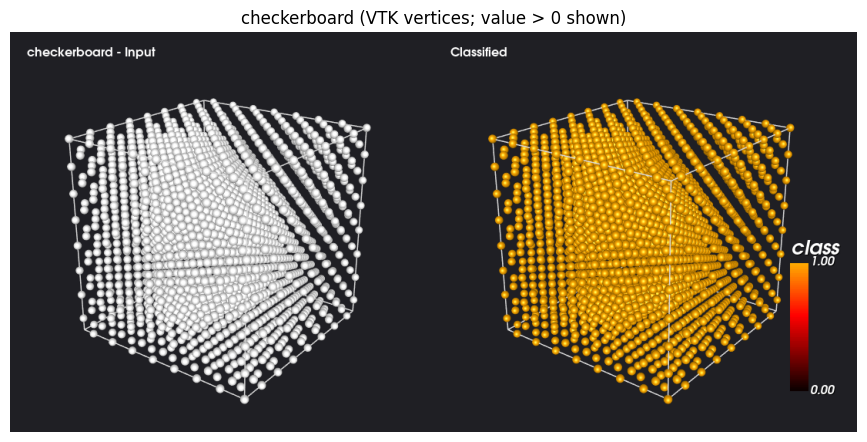

In [45]:
isolevel = 128

# 1D
datasets_1D = construct_1D_datasets()
outputs_1D = {}

for name, data in datasets_1D.items():
    outputs_1D[name] = (data > isolevel).astype(int)

visualize_classification_1D(datasets_1D, outputs_1D)


# 2D
datasets_2D = construct_2D_datasets()
outputs_2D = {}

for name, data in datasets_2D.items():
    outputs_2D[name] = (data > isolevel).astype(int)

visualize_classification_2D(datasets_2D, outputs_2D)


# 3D (VTK)
datasets_3D = construct_3D_datasets()
outputs_3D = {}

for name, data in datasets_3D.items():
    outputs_3D[name] = (data > isolevel).astype(int)

visualize_classification_3D(datasets_3D, outputs_3D)


In [46]:
# EOF

In [47]:
T = [0.9, 0.51, 0.5, 0, -0.5, -0.9]

for t in T:
    w = t / (1 - t)
    print(f"t: {t}, w: {w}")

    a = np.arccos(1 - 2 * w)
    print(f"a: {a}")


t: 0.9, w: 9.000000000000002
a: nan
t: 0.51, w: 1.0408163265306123
a: nan
t: 0.5, w: 1.0
a: 3.141592653589793
t: 0, w: 0.0
a: 0.0
t: -0.5, w: -0.3333333333333333
a: nan
t: -0.9, w: -0.4736842105263158
a: nan


C:\Users\waffles\AppData\Local\Temp\ipykernel_23100\3263404739.py:7: RuntimeWarning: invalid value encountered in arccos
  a = np.arccos(1 - 2 * w)


In [ ]:
# add method to render triangles
# contour filter class